In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


import os, copy
import glob

import matplotlib as mpl
#mpl.use('tkagg')
import matplotlib.pyplot as plt

plt.rcParams.update({'font.family': 'Times New Roman',
                     'font.size': 16, 'axes.labelsize': 18,

                     })

rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

import numpy as np
import scipy.optimize as so
import pandas as pd
import xarray as xr
import rioxarray as rxr
import datetime as dt

import netCDF4
import h5py
from osgeo import gdal
from matplotlib.backends.backend_pdf import PdfPages

import colorcet as cc


from aeronet_visu import data_loading as dl

In [2]:
opj = os.path.join
aeronet_dir = '/DATA/AERONET/OCv3/'
workdir = '/data/acix-iii'
odir = '/data/acix-iii/matchup'


sites=[  ['ariaketower','ARIAKE_TOWER'],
         ['bahiablanca','Bahia_Blanca'],
         ['casablanca','Casablanca_Platform'],
         ['galataplatform','Galata_Platform'],
         ['gustavdalentower','Gustav_Dalen_Tower'],
         ['irbelighthouse','Irbe_Lighthouse'],
         ['kemigawa','Kemigawa_Offshore'],
         ['lakeerie','Lake_Erie'],
         ['lakeokeechobee','Lake_Okeechobee_N'],
         ['lisco','LISCO'],
         ['lucinda','Lucinda'],
         ['palgrunden','Palgrunden'],
         ['sanmarcoplatform','San_Marco_Platform'],
         ['section7','Section-7_Platform'],
         ['socheongcho','Socheongcho'],
         ['southgreenbay','South_Greenbay'],
         ['uscseaprism','USC_SEAPRISM_2'],
         ['venezia','Venise'],
         ['wavecissite','WaveCIS_Site_CSI_6'],
         ['zeebrugge','Zeebrugge-MOW1']]

irr = dl.irradiance()
irr.load_F0()

params = ['Lwn','Lwn_IOP','Lwn_f/Q']

Ttot_Ed=xr.open_dataset('/DATA/git/satellite_app/hgrs/data/lut/transmittance_downward_irradiance.nc')
ratio_kurucz_thuillier=xr.open_dataarray('/DATA/git/satellite_app/hgrs/data/aux/ratio_kurucz_thuillier.nc')
ratio_kurucz_gueymard=xr.open_dataarray('/DATA/git/satellite_app/hgrs/data/aux/ratio_kurucz_gueymard.nc')
lut_file = '/DATA/git/satellite_app/hgrs/data/lut/opac_osoaa_lut_v3.nc'
aero_lut = xr.open_dataset(lut_file)
aero_lut['wl']=aero_lut['wl']*1000

def find_nearest(arr, lon, lat):
    abslat = np.abs(arr.lat - lat)
    abslon = np.abs(arr.lon - lon)
    dist = np.maximum(abslon, abslat)
    return np.unravel_index(dist.argmin(), arr.lon.shape)

In [3]:
# ---------------------------------------------
# Main loop
# ---------------------------------------------
suff='v2'
site=['bahiablanca','Bahia_Blanca']

 
prisma_site,aeronet_site = site
#if os.path.exists(opj(odir, 'fig', 'Rrs_matchup_' + aeronet_site + '.png')):
#    continue
# ---------------------------------------------
# LOAD AERONET-OC data
# ---------------------------------------------
file = aeronet_site+'_OCv3.lev15'
df = dl.read(opj(aeronet_dir, file)).read_aeronet_ocv3()

df = df.droplevel(0, 1)
# criteria to select scalar and spectrum values
criteria = df.columns.get_level_values(1) == ''
df_att = df.loc[:, criteria].droplevel(1, 1)
df_spec = df.loc[:, ~criteria]

ds = df_spec.stack().to_xarray()
ds = xr.merge([ds, df_att.to_xarray()])
del df

ds = ds.assign_coords({'level_1': ds.level_1.astype(float)}).rename({'level_1': "wl"})
ds['SZA'] = ds.Solar_Zenith_Angle.mean(axis=1)
ds['year']=ds['date.year']
ds['season']=ds['date.season']

wl = ds.wavelength * 1000
for param in params:
    ds['Rrs_'+param] = ds[param] / (irr.get_F0(wl) * 0.1)
ds=ds.sortby("wl")

lat,lon = ds['Site_Latitude(Degrees)'].mean().values,ds['Site_Longitude(Degrees)'].mean().values
print(lat,lon)

/home/harmel/anaconda3/envs/grstbx/lib/python3.9/site-packages/aeronet_visu-1.0.0-py3.9.egg/aeronet_visu/data_loading.py:30: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv(ifile, skiprows=skiprows, na_values=['N/A', -999.0,-9.999999 ], parse_dates={'date': [1, 2]},


-39.148332999999994 -61.72166700000002


In [4]:
#with PdfPages('multipage_pdf.pdf') as pdf:
# ---------------------------------------------
# Load PRISMA data
# ---------------------------------------------
dc=[]
for file in sorted(glob.glob(opj(workdir,prisma_site,'*'+suff+'*.nc'))):

    print(file)
    img =xr.open_dataset(file)
    date = dt.datetime.strptime(img.acquisition_date,'%Y-%m-%dT%H:%M:%S.%f')
    #img.acquisition_date


    sza=np.nanmean(img.sza)
    vza= np.nanmean(img.vza)
    aot_ref= np.nanmean(img.aot_ref)
    model = img.aerosol_model
    wl =img.wl
    #ratio_irr = ratio_kurucz_gueymard.interp(wl=wl)
    if False:
        Ttot_Ed_ = Ttot_Ed.Ttot_Ed.sel(model=model).interp(sza=sza, method='cubic').interp(aot_ref=aot_ref, method='quadratic').interp(wl=wl, method='cubic')
        Ttot_Lu_ = Ttot_Ed.Ttot_Ed.sel(model=model).interp(sza=vza, method='cubic').interp(aot_ref=aot_ref, method='quadratic').interp(wl=wl, method='cubic')**1.05
        Ttot = (Ttot_Ed_ *Ttot_Lu_).reset_coords(drop=True)
        param = 'Rrs' #Rtoa'
        #img = prod[['Rtoa','Ltoa']]
        img[param] = img[param]/Ttot #* ratio_irr**5

    dc.append(img)

/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20200227141431_20200227141435_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20210414141410_20210414141414_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20210814141750_20210814141755_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20210825140800_20210825140804_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20210923140805_20210923140810_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20211010140139_20211010140144_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20211103141458_20211103141502_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20211114140502_20211114140507_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20211207140145_20211207140150_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20211231141454_20211231141458_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20220227141812_20220227141816_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv2_20220402140443_20220402140447_0001.nc
/data/acix-iii/bahiablanca/PRS_L2A_hGRSv

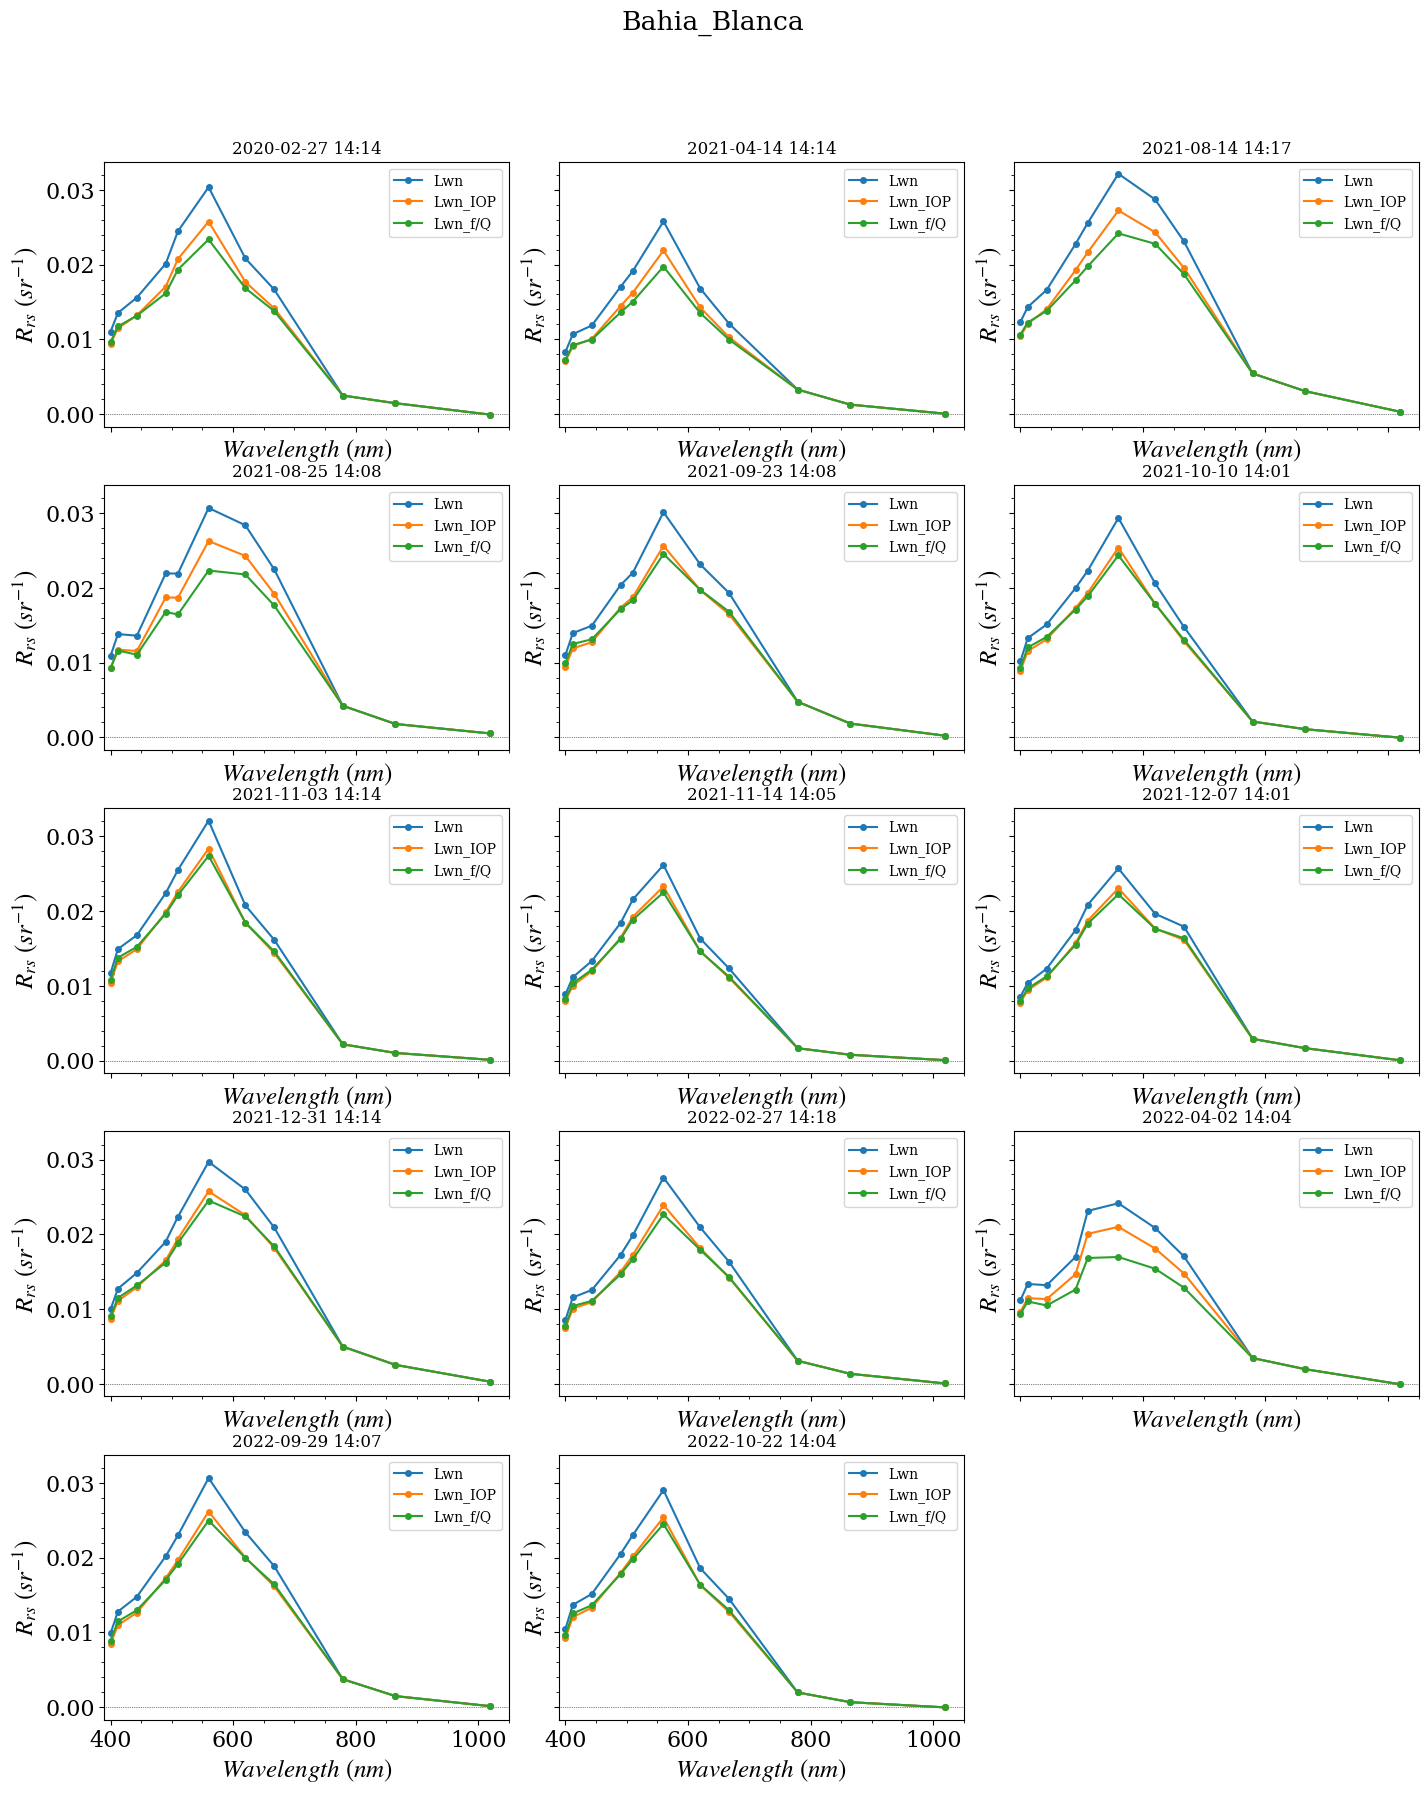

In [5]:
find_nearest(dc[0],float(lon),float(lat))

ncols=3
nrows=int(np.ceil(len(dc)/ncols))


fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*4.9,3.5*nrows+1.5),sharey=True,sharex=True)
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.22, wspace=0.125)
axs=axs.ravel()
for ax in axs:
    ax.set_visible(False)
for i_, img in enumerate(dc):
    axs[i_].set_visible(True)
    axs[i_].minorticks_on()
    date= dt.datetime.strptime(img.acquisition_date,'%Y-%m-%dT%H:%M:%S.%f')

 
    for param in params:
        ds['Rrs_'+param].sel(date=str(date),method='nearest').dropna('wl').plot(x='wl',marker='o',ms=4,label=param,ax=axs[i_])
    axs[i_].set_ylabel('$R_{rs}\ (sr^{-1})$')
    axs[i_].hlines(0,390,1100,ls=':',lw=0.5,color='black',zorder=0)
    axs[i_].set_xlabel('$Wavelength\ (nm)$')
    axs[i_].set_title(date.strftime('%Y-%m-%d %H:%M'),fontsize=12)
    axs[i_].legend(fontsize=10)
axs[0].set_xlim(390,1050)
#plt.tight_layout()
plt.suptitle(aeronet_site)
plt.show()

In [ ]:
# ---------------------------------------------
# Plot match-up data
# ---------------------------------------------

find_nearest(dc[0],float(lon),float(lat))

ncols=3
nrows=int(np.ceil(len(dc)/ncols))


fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*4.9,3.5*nrows+1.5),sharey=True,sharex=True)
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.22, wspace=0.125)
axs=axs.ravel()
for ax in axs:
    ax.set_visible(False)
for i_, img in enumerate(dc):
    axs[i_].set_visible(True)
    axs[i_].minorticks_on()
    date= dt.datetime.strptime(img.acquisition_date,'%Y-%m-%dT%H:%M:%S.%f')

    xcenter,ycenter=find_nearest(img,lon,lat)
    if xcenter > 995:
        xcenter=995

    for i in range(6):
        for j in range(6):
            img.Rrs.isel(x=xcenter+i-2,y=ycenter+j-2).plot(x='wl',color='black',alpha=0.5,lw=0.7,ax=axs[i_])#,label='PRISMA')
            #img.Rrs_corr.isel(x=xcenter+i-2,y=ycenter+j-2).plot(x='wl',color='black',alpha=0.5,lw=0.7,ax=axs[i_])#,label='PRISMA')
    for param in params:
        ds['Rrs_'+param].sel(date=str(date),method='nearest').dropna('wl').plot(x='wl',marker='o',ms=4,label=param,ax=axs[i_])
    axs[i_].set_ylabel('$R_{rs}\ (sr^{-1})$')
    axs[i_].hlines(0,390,1100,ls=':',lw=0.5,color='black',zorder=0)
    axs[i_].set_xlabel('$Wavelength\ (nm)$')
    axs[i_].set_title(date.strftime('%Y-%m-%d %H:%M'),fontsize=12)
    axs[i_].legend(fontsize=10)
axs[0].set_xlim(390,1050)
#plt.tight_layout()
plt.suptitle(aeronet_site)


In [ ]:
hours=6
delta = dt.timedelta(hours=hours/2)

fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*4.9,3.5*nrows+1.5),sharey=True,sharex=True)
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.22, wspace=0.125)
axs=axs.ravel()
for ax in axs:
    ax.set_visible(False)
for i_, img in enumerate(dc):
    axs[i_].set_visible(True)
    axs[i_].minorticks_on()
    date= dt.datetime.strptime(img.acquisition_date,'%Y-%m-%dT%H:%M:%S.%f')
    p = ds['Aerosol_Optical_Depth'].sel(date=slice(date-delta,date+delta)).dropna('wl')
    if len(p.date) > 0:
        p.plot(x='wl',marker='o',ms=4,hue='date',lw=0.7,ax=axs[i_],add_legend=False)

    for i in range(6):
        for j in range(6):
            aot_ref=img.aot_ref_full.isel(x=xcenter+i-2,y=ycenter+j-2).values
            axs[i_].plot(550,aot_ref,color='black',marker='o',ms=5,alpha=0.5)
            aero_lut.aot.sel(model=img.aerosol_model).interp(aot_ref=aot_ref
                            ).interp(wl=np.linspace(390,1010,200),method='cubic').plot(ax=axs[i_],lw=1.2,color='black')
    axs[i_].set_title(str(date.date()))
    axs[i_].set_ylabel('$Aerosol\ Optical\ Depth$')
    axs[i_].set_xlabel('$Wavelength\ (nm)$')
    axs[i_].set_title(date.strftime('%Y-%m-%d %H:%M'), fontsize=12)
    axs[i_].legend([img.aerosol_model])
plt.suptitle(aeronet_site)

plt.savefig(opj(odir, 'fig', 'AOD_matchup_' + aeronet_site+suff + '.png'), dpi=300)
pdf.savefig()
plt.close()